2026-03-12 12:32:26.522050: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Original training set shape: (38840, 4)
SMOTE training set shape: (58260, 4)
Class distribution after SMOTE: [29130 29130]
Use /var/folders/wn/xdcqjsfn1q37gf381p3xc6500000gn/T/tmp2ftp7q4z as temporary training directory
Reading training dataset...
Training dataset read in 0:00:04.300643. Found 58260 examples.
Training model...


[INFO 26-03-12 12:32:46.5878 PDT kernel.cc:1233] Loading model from path /var/folders/wn/xdcqjsfn1q37gf381p3xc6500000gn/T/tmp2ftp7q4z/model/ with prefix 92830bfdfb454be4
[INFO 26-03-12 12:32:46.7769 PDT decision_forest.cc:734] Model loaded with 300 root(s), 65934 node(s), and 4 input feature(s).
[INFO 26-03-12 12:32:46.7769 PDT abstract_model.cc:1344] Engine "RandomForestOptPred" built
[INFO 26-03-12 12:32:46.7769 PDT kernel.cc:1061] Use fast generic engine


Model trained in 0:00:05.049857
Compiling model...
Model compiled.

VALIDATION RESULTS
2738/2738 [==============================] - 53s 19ms/step
-------------------------
Classification Report
-------------------------
              precision    recall  f1-score   support

           0       1.00      0.55      0.71   2735348
           1       0.00      0.85      0.00      2081

    accuracy                           0.55   2737429
   macro avg       0.50      0.70      0.36   2737429
weighted avg       1.00      0.55      0.71   2737429



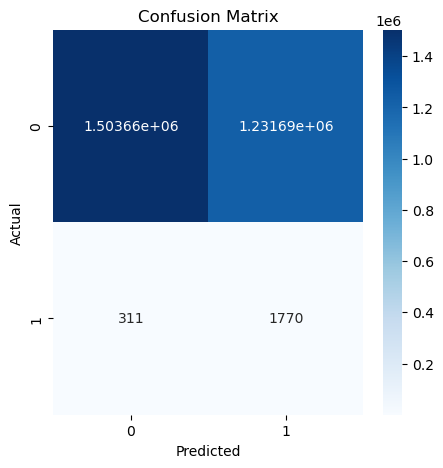


TEST RESULTS
2738/2738 [==============================] - 51s 19ms/step
-------------------------
Classification Report
-------------------------
              precision    recall  f1-score   support

           0       1.00      0.55      0.71   2735349
           1       0.00      0.84      0.00      2080

    accuracy                           0.55   2737429
   macro avg       0.50      0.70      0.36   2737429
weighted avg       1.00      0.55      0.71   2737429



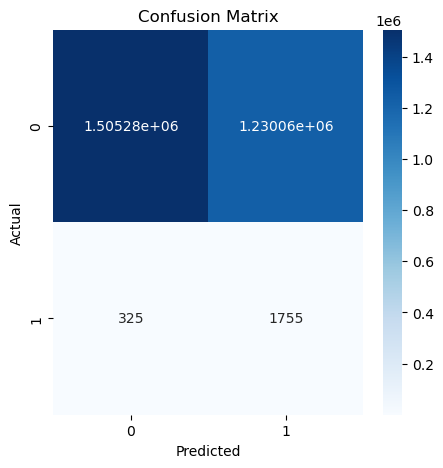

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_decision_forests as tfdf
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Load Data
# -----------------------------

MODIS_FIRMS_TRAIN_VAL_TEST_DATASET = '../data/processed/modis_firms_train_val_test_dataset.npz'

data = np.load(MODIS_FIRMS_TRAIN_VAL_TEST_DATASET)

X_train = data["X_train"]
y_train = data["y_train"]
X_train_balanced = data["X_train_balanced"]
y_train_balanced = data["y_train_balanced"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

feature_names = ["NDVI", "EVI", "LST_Day", "LST_Night"]

# -----------------------------
# 2. Apply SMOTE to Training Data
# -----------------------------

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_balanced, y_train_balanced)

print(f"Original training set shape: {X_train_balanced.shape}")
print(f"SMOTE training set shape: {X_train_smote.shape}")
print(f"Class distribution after SMOTE: {np.bincount(y_train_smote)}")

# -----------------------------
# 3. Convert to DataFrames
# -----------------------------

train_df = pd.DataFrame(X_train_smote, columns=feature_names)
train_df["label"] = y_train_smote

val_df = pd.DataFrame(X_val, columns=feature_names)
val_df["label"] = y_val

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df["label"] = y_test

# -----------------------------
# 4. Convert DataFrames to TF-DF Datasets
# -----------------------------

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df, label="label")
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(val_df, label="label")
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="label")

# -----------------------------
# 5. Train Random Forest Model
# -----------------------------

model = tfdf.keras.RandomForestModel(
    num_trees=300,
    max_depth=8
)

model.fit(train_ds)

# -----------------------------
# 6. Evaluation Function
# -----------------------------

def evaluate_model(model, dataset, y_true, threshold=0.3):

    # TF-DF returns probability of class 1
    y_prob = model.predict(dataset).reshape(-1)

    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)

    cnf_matrix = confusion_matrix(y_true, y_pred)

    print("-" * 25)
    print("Classification Report")
    print("-" * 25)
    print(classification_report(y_true, y_pred))

    plt.figure(figsize=(5,5))
    sns.heatmap(cnf_matrix, annot=True, fmt="g", cmap=plt.cm.Blues)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    return y_pred

# -----------------------------
# 7. Evaluate on Validation and Test Sets
# -----------------------------

print("\nVALIDATION RESULTS")
y_val_pred = evaluate_model(model, val_ds, y_val, threshold=0.3)

print("\nTEST RESULTS")
y_test_pred = evaluate_model(model, test_ds, y_test, threshold=0.3)